## Exploratory Data Analysis — Part 1

In this notebook, we perform the first stage of exploratory data analysis (EDA) to better understand the wildfire dataset and its relationship to the problem of early wildfire risk prediction.

The goal of this competition is to estimate the probability that a wildfire will come within **5 km of an evacuation zone** within multiple time horizons (12h, 24h, 48h, and 72h), using only the information available during the **first five hours after ignition**.

To support this objective, the analysis in this notebook focuses on understanding the structure and behavior of the available features. The key aspects explored in this part include:

- Reviewing the **dataset metadata and feature definitions**
- Examining **categorical, binary, and count features** using value distributions
- Investigating **continuous feature statistics** using summary statistics
- Identifying **data distribution patterns and skewness**
- Detecting **outliers using the IQR method**
- Exploring **temporal features** such as fire start hour, day of week, and month

Through this analysis, we aim to understand the characteristics of early wildfire behavior, including fire growth, movement patterns, spatial relationships to evacuation zones, and temporal patterns of wildfire occurrence.

This foundational analysis helps identify important patterns and potential challenges in the dataset, which will guide further analysis and modeling in the next stages of the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# loading Data

df_train = pd.read_csv('../Data/train.csv')
df_metadata = pd.read_csv('../Data/metaData.csv')
df_train.sample(5)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
139,65120642,4,4.640813,0,420.398730,352.032424,0.837377,75.855761,6.043579,5.86656,...,0.658097,0.796469,0.796469,71.511,94.192518,17,2,6,2.483279,0
74,39687487,2,1.424188,0,2.011464,0.000000,0.000000,0.000000,1.102426,0.00000,...,0.000000,0.488864,0.488864,0.000,0.000000,19,0,9,0.743442,1
176,80087496,1,0.000000,1,258.150907,0.000000,0.000000,0.000000,5.557411,0.00000,...,0.000000,0.000000,0.000000,0.000,0.000000,21,5,8,66.790141,0
142,66678641,1,0.000000,1,123.421747,0.000000,0.000000,0.000000,4.823677,0.00000,...,0.000000,0.000000,0.000000,0.000,0.000000,5,1,8,7.488617,1
162,73362817,1,0.000000,1,67.560539,0.000000,0.000000,0.000000,4.227717,0.00000,...,0.000000,0.000000,0.000000,0.000,0.000000,19,1,7,19.561849,1


# Understanding the Metadata and Feature Definitions

In [20]:
df_metadata.head(4)

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN


## Feature Type Grouping

In [16]:

# COLUMN TYPE GROUPING


# TARGET + IDENTIFIER


ID_COL = ["event_id"]
TARGET_COLS = ["time_to_hit_hours", "event"]


# CATEGORICAL COUNT FEATURES


categorical_count = [
    "num_perimeters_0_5h"
]


# TIME / TEMPORAL FEATURES


time_features = [
    "dt_first_last_0_5h",
    "event_start_hour",
    "event_start_dayofweek",
    "event_start_month"
]


# BINARY / LOW CARDINALITY FEATURES


categorical = [
    "low_temporal_resolution_0_5h"
]


# CONTINUOUS FEATURES


continuous = [
    "area_first_ha",
    "area_growth_abs_0_5h",
    "area_growth_rel_0_5h",
    "area_growth_rate_ha_per_h",
    "log1p_area_first",
    "log1p_growth",
    "log_area_ratio_0_5h",
    "relative_growth_0_5h",
    "radial_growth_m",
    "radial_growth_rate_m_per_h",
    "centroid_displacement_m",
    "centroid_speed_m_per_h",
    "spread_bearing_deg",
    "spread_bearing_sin",
    "spread_bearing_cos",
    "dist_min_ci_0_5h",
    "dist_std_ci_0_5h",
    "dist_change_ci_0_5h",
    "dist_slope_ci_0_5h",
    "closing_speed_m_per_h",
    "closing_speed_abs_m_per_h",
    "projected_advance_m",
    "dist_accel_m_per_h2",
    "dist_fit_r2_0_5h",
    "alignment_cos",
    "alignment_abs",
    "cross_track_component",
    "along_track_speed"
]


# ALL FEATURES


ALL_FEATURES = continuous + categorical + categorical_count + time_features

print("Continuous:", len(continuous))
print("Categorical:", len(categorical))
print("Categorical Count:", len(categorical_count))
print("Time Features:", len(time_features))
print("Total Features:", len(ALL_FEATURES))


Continuous: 28
Categorical: 1
Categorical Count: 1
Time Features: 4
Total Features: 34


## Summary of Categorical and Count-Based Features

In [22]:
df_train.columns
df_train[[df_train.columns[1]]].value_counts()


num_perimeters_0_5h
1                      160
2                       25
3                        7
7                        7
4                        5
5                        5
12                       5
6                        2
9                        2
11                       1
13                       1
17                       1
Name: count, dtype: int64

### num_perimeters_0_5h

This feature represents the **number of wildfire perimeter observations recorded within the first five hours after ignition (t0)**. It reflects how frequently the fire boundary was updated during the early monitoring period.

#### Statistical Distribution

The distribution of this feature is **highly skewed toward low values**.

| Number of Perimeters | Count |
|---|---|
| 1 | 160 |
| 2 | 25 |
| 3 | 7 |
| 4 | 5 |
| 5 | 5 |
| 6 | 2 |
| 7 | 7 |
| 9 | 2 |
| 11 | 1 |
| 12 | 5 |
| 13 | 1 |
| 17 | 1 |

Key statistics:

- **Total events:** 221
- **Single observation (1 perimeter):** 160 events (~72%)
- **Two observations:** 25 events (~11%)
- **Three or more observations:** 36 events (~16%)

The **median value is 1**, indicating that for more than half of the fires, only a single perimeter observation was available in the first five hours.

#### Distribution Characteristics

The feature shows a **strong right-skewed distribution** with a long tail extending to higher values (up to 17 observations). These higher values likely correspond to fires that were monitored more frequently due to operational importance or higher activity levels.

#### Interpretation

This distribution highlights a key limitation of early wildfire monitoring: most fires have **very limited perimeter observations during the initial hours after ignition**. As a result, early-stage fire dynamics such as growth rate and movement may be estimated with limited temporal information for a large portion of events.

Fires with more perimeter observations provide richer temporal information, potentially allowing more accurate estimation of early spread behavior.

In [23]:
df_train.columns
df_train[categorical].value_counts()


low_temporal_resolution_0_5h
1                               161
0                                60
Name: count, dtype: int64

### `low_temporal_resolution_0_5h`

 `Hindi` (Ye column batata hai ki first 5 hours me fire monitoring kitni achhi hui thi.)

This feature is a **binary indicator** describing the temporal resolution of perimeter observations during the first five hours after the initial fire detection.

- **1** → Low temporal resolution (either only one perimeter observation or the time span between observations is less than 0.5 hours)
- **0** → Adequate temporal resolution with multiple observations over time

#### Statistical Distribution

| Value | Count |
|------|------|
| 1 (Low temporal resolution) | 161 |
| 0 (Adequate temporal resolution) | 60 |

Key statistics:

- **Total events:** 221
- **Low temporal resolution:** 161 fires (~72.9%)
- **Adequate temporal resolution:** 60 fires (~27.1%)

#### Distribution Characteristics

The dataset is **strongly dominated by low temporal resolution events**, with nearly three-quarters of the fires having limited perimeter observations during the first five hours.

This aligns closely with the distribution observed in `num_perimeters_0_5h`, where most fires had only a single recorded perimeter. This indicates that early wildfire monitoring often captures only sparse observations, limiting the amount of dynamic information available during the critical early phase of the incident.

#### Interpretation

Low temporal resolution suggests that early fire behavior (such as growth rate, movement direction, and distance change) may be estimated with **higher uncertainty** for a large portion of the dataset. Fires with adequate temporal resolution provide more reliable measurements of early spread dynamics, as multiple perimeter observations allow better estimation of growth and movement trends within the five-hour observation window.

## Continuous Feature Statistical Summary


In [25]:
df_train[continuous].describe().T

,count,mean,std,min,25%,50%,75%,max
area_first_ha,221.0,619.131641,1447.723668,3.752484e-02,25.219058,110.149250,485.092561,11942.392115
area_growth_abs_0_5h,221.0,26.332398,187.437018,-2.156175e-05,0.000000,0.000000,0.000000,2508.041442
area_growth_rel_0_5h,221.0,0.178909,1.302001,-1.437844e-07,0.000000,0.000000,0.000000,17.889695
area_growth_rate_ha_per_h,221.0,6.167128,40.467370,-5.292846e-06,0.000000,0.000000,0.000000,520.443033
log1p_area_first,221.0,4.683276,2.083529,3.683791e-02,3.266487,4.710874,6.186399,9.387933
log1p_growth,221.0,0.389346,1.340348,0.000000e+00,0.000000,0.000000,0.000000,7.827656
log_area_ratio_0_5h,221.0,0.065434,0.300321,-1.437844e-07,0.000000,0.000000,0.000000,2.938617
relative_growth_0_5h,221.0,0.178909,1.302001,-1.437844e-07,0.000000,0.000000,0.000000,17.889695
radial_growth_m,221.0,29.429575,144.879769,-4.966987e-05,0.000000,0.000000,0.000000,1351.378212
radial_growth_rate_m_per_h,221.0,7.770330,37.840514,-1.219265e-05,0.000000,0.000000,0.000000,352.441687


## Conclusion from Continuous Feature Statistics

The statistical summary of continuous variables highlights several key patterns in the wildfire dataset.

1. **Right-Skewed Distributions**  
Many features show large differences between the mean and median, indicating right-skewed distributions. Most fires start relatively small, while a few extremely large fires significantly influence the averages.

2. **Limited Early Growth**  
Several growth-related features have median values close to zero, suggesting that most fires show little measurable expansion during the first five hours after ignition.

3. **Extreme Growth in Few Cases**  
A small number of fires exhibit very large growth values, representing rapidly developing events that may pose greater risk.

4. **Large Distance Variability**  
Fires occur at widely varying distances from evacuation zones, with some events located hundreds of kilometers away.

5. **Minimal Early Movement**  
Many fires show little centroid movement in the early stage, although a few events display significant displacement.

Overall, most fires remain relatively stable during the early observation window, while a small subset shows rapid growth or movement that could increase risk to nearby evacuation zones.

## Conclusion from Continuous Feature Statistics

The statistical summary of continuous variables reveals several important patterns in the wildfire dataset.

1. **Strong Right-Skewed Distributions**

Many features show large differences between the mean and median values, indicating highly right-skewed distributions. For example, the initial fire area (`area_first_ha`) has a mean of about 619 hectares while the median is only about 110 hectares, with extreme values exceeding 11,000 hectares. This suggests that most fires are relatively small, but a few very large fires significantly influence the averages.

2. **Limited Early Growth for Most Fires**

Several growth-related features have median and 75th percentile values equal to zero. This indicates that a large proportion of fires show little or no measurable expansion during the first five hours after ignition. Early wildfire behavior is therefore often relatively stable for many incidents.

3. **Presence of Extreme Growth Events**

Although most fires show minimal early activity, a small subset of fires exhibits very large growth values. For example, absolute area growth can exceed 2,500 hectares within the early observation window. These extreme cases represent rapidly developing fires that may pose greater risk.

4. **Large Variation in Distance to Evacuation Zones**

The distance between fires and evacuation zones varies widely. The median distance is about 31 km, while some fires occur hundreds of kilometers away from evacuation zones. This indicates substantial variability in the spatial relationship between wildfire events and populated areas.

5. **Minimal Early Fire Movement**

Centroid movement features also show median values of zero, suggesting that many fires do not exhibit significant spatial movement during the early observation period. However, a few fires display substantial displacement and movement speed.

Overall, the dataset suggests that most wildfires show limited measurable activity in the early hours, while a small number of events exhibit rapid growth or movement. These rare but extreme cases likely represent the fires that pose the greatest potential risk to nearby evacuation zones.

`Hindi`<br>Most wildfires early 5 hours me slow aur stable hote hain,
lekin kuch fires rapidly grow karke high-risk incidents ban jate hain.

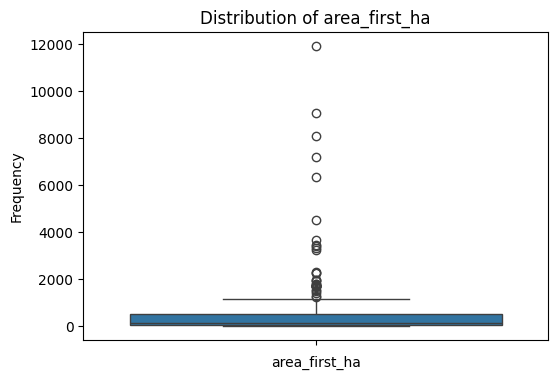

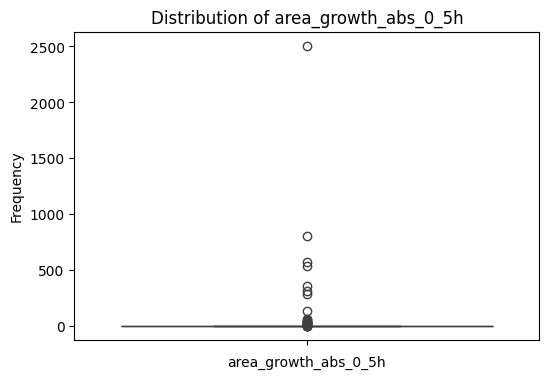

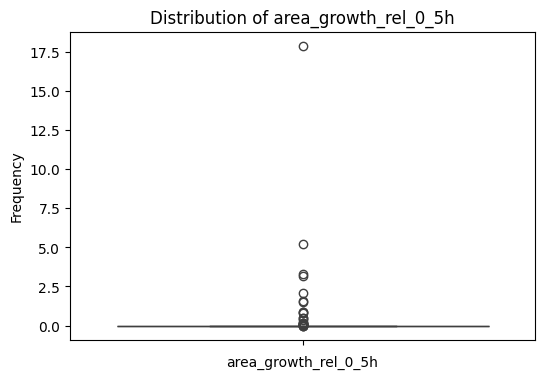

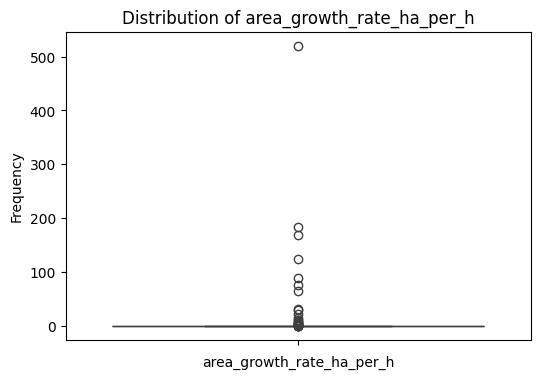

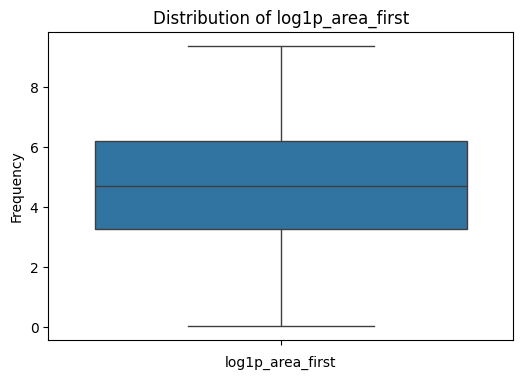

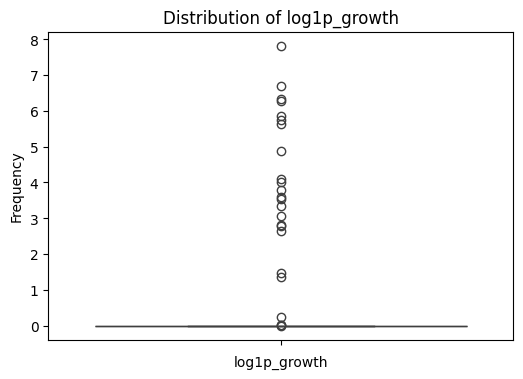

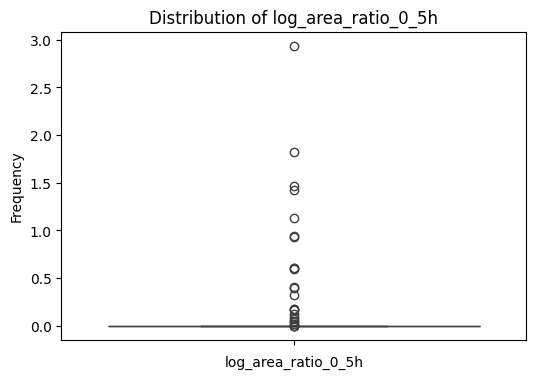

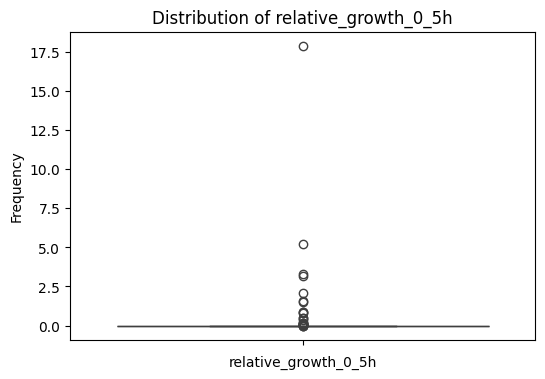

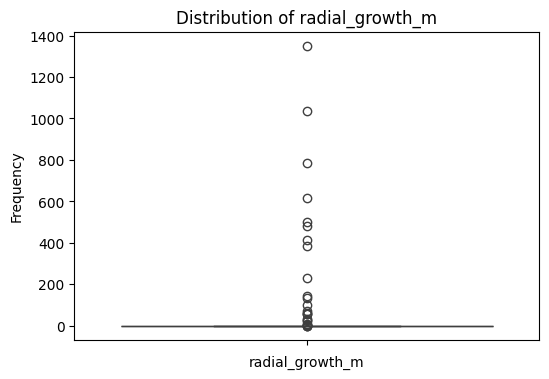

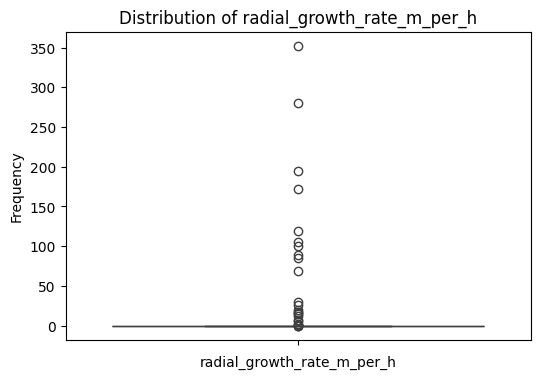

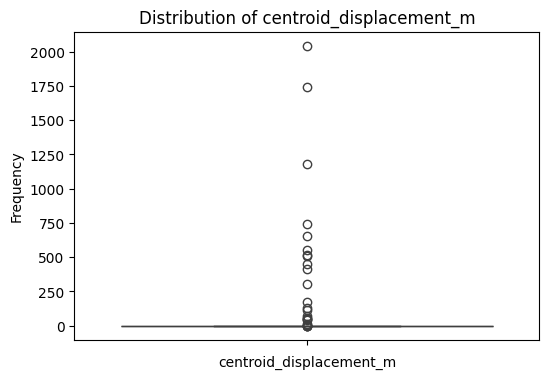

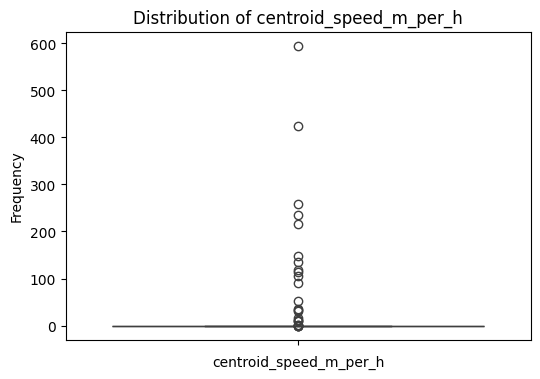

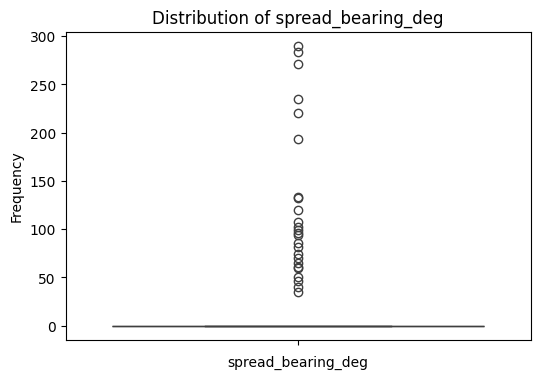

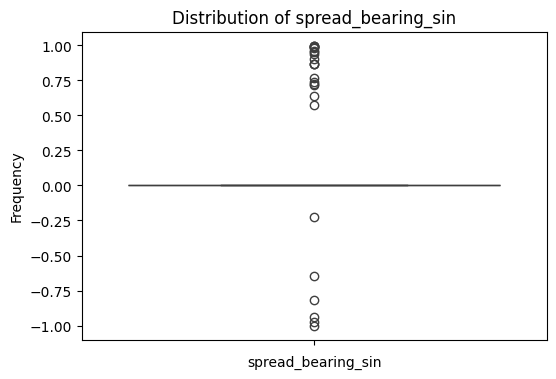

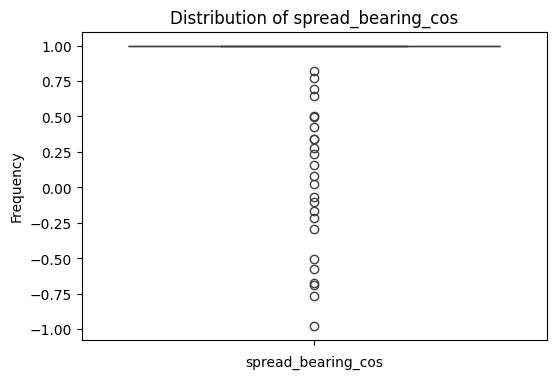

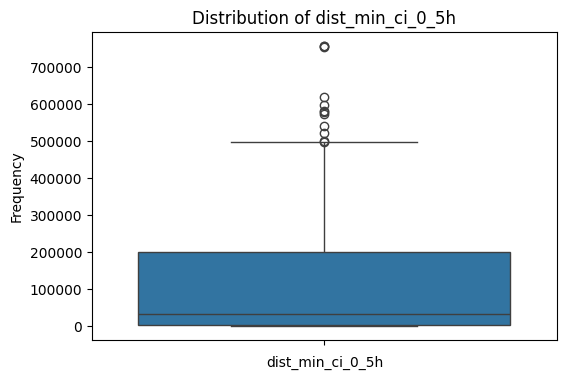

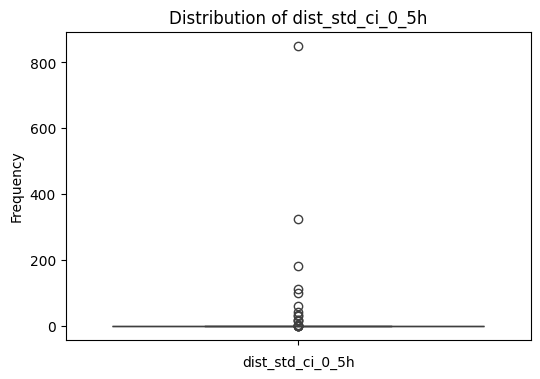

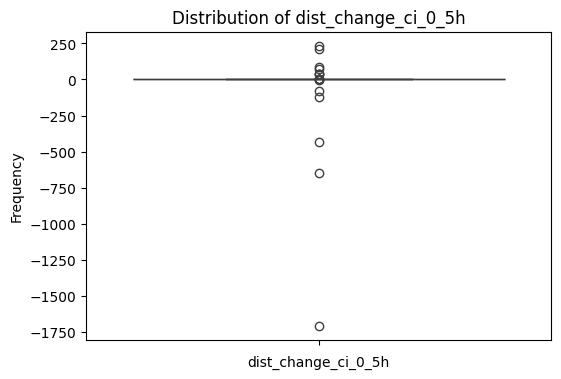

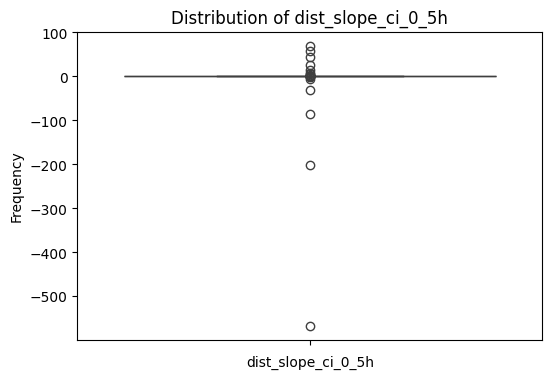

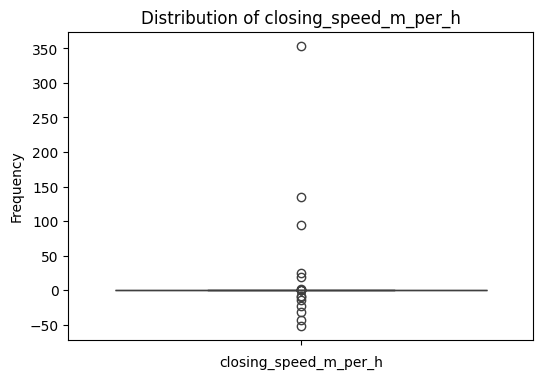

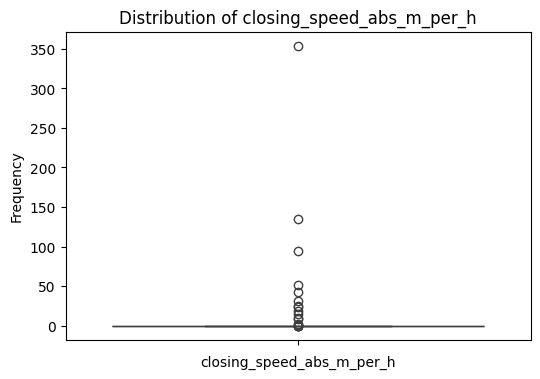

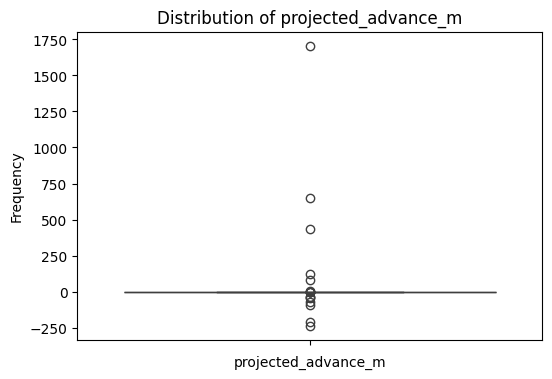

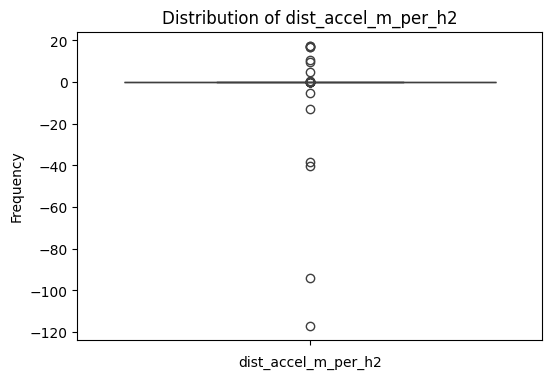

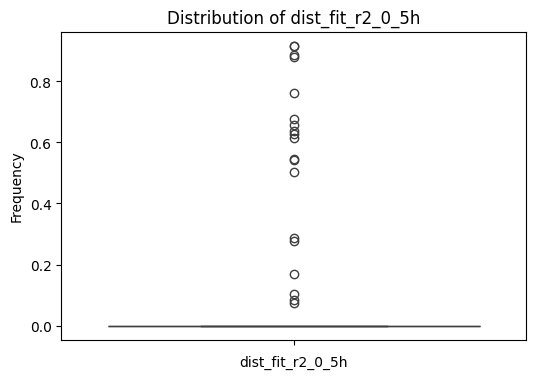

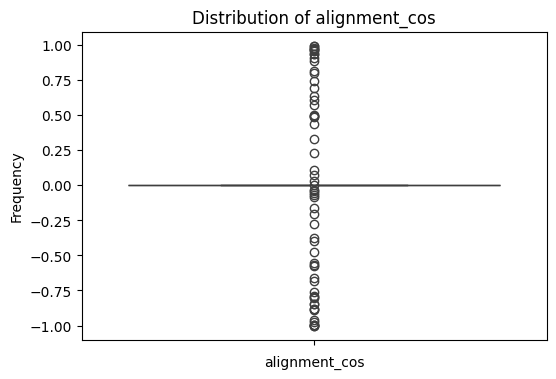

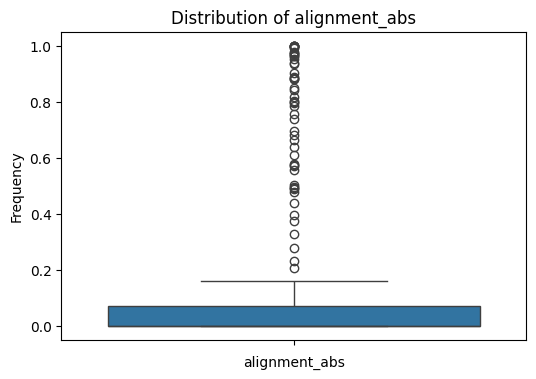

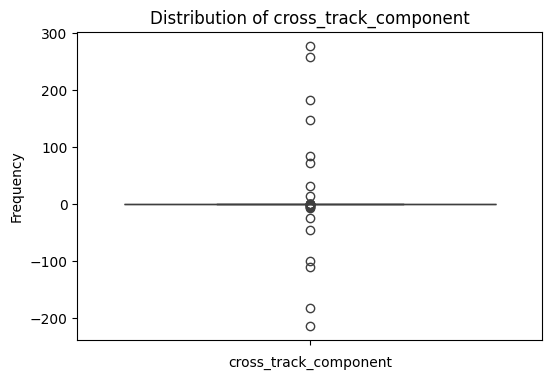

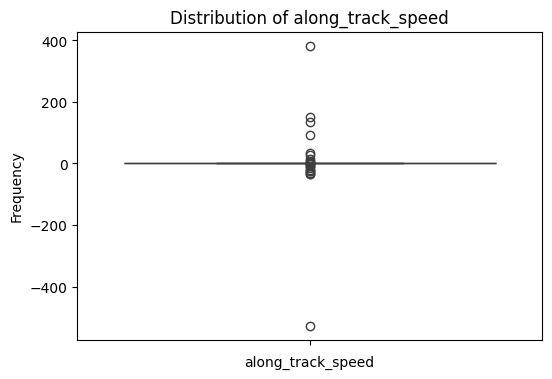

In [ ]:
for i in continuous:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df_train[i])
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()
    

In [27]:
import pandas as pd

outlier_dict = {}

for col in continuous:
    
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_train[(df_train[col] < lower) | (df_train[col] > upper)][col]
    
    outlier_dict[col] = outliers.values
    
    print(f"\n🔹 {col}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Outliers Count: {len(outliers)}")
    print(outliers.values)


🔹 area_first_ha
Lower Bound: -664.59119771086
Upper Bound: 1174.9028168015502
Outliers Count: 32
[ 1388.28377808  1749.27871612  3638.72998334  1255.87802314
  2300.00904797  3316.03739653  3434.82778237  1682.29666724
  6319.91836894  1686.85091666  1920.87552554  1769.24792882
  4518.73810873  1668.03413946  3216.55458384  2246.58953143
  1683.81287225 11942.39211484  1671.49953036  1218.9132637
  8092.57096338  1630.3896249   1951.61387441  1668.66925928
  7197.11788356  2221.46447677  1777.623176    1925.57410131
  1458.73131891  9082.0761509   1504.49881618  3403.02184165]

🔹 area_growth_abs_0_5h
Lower Bound: 0.0
Upper Bound: 0.0
Outliers Count: 25
[ 2.87593461e+00  2.02626934e+01  3.53212526e+01  5.38626524e+01
  2.87892240e-01  1.30909565e+01  1.29616920e-03  3.02368342e-02
  1.54713288e+01  1.50325506e+01  3.14052044e+02  4.28565397e+01
  1.30775790e+02  5.68808820e+02  2.50804144e+03  2.76108675e+01
  3.52032424e+02  8.06551870e+02  5.36082195e+02  3.31197354e+01
  3.32796432

## Outlier Analysis Conclusion

The outlier analysis reveals several important characteristics of the dataset.

First, many growth and movement-related features have a large number of zero values. This indicates that most fires show minimal measurable growth or movement during the first five hours after ignition.

Second, a small subset of fires exhibits extremely large values in features such as initial fire area, growth metrics, and movement variables. These represent rare but rapidly developing wildfire events that may pose greater risk.

Finally, log-transformed features (such as `log1p_area_first`) show significantly fewer outliers, suggesting that logarithmic transformation helps stabilize highly skewed distributions.

Overall, the dataset suggests that while most fires remain relatively stable during the early observation window, a small number of fires display extreme growth or movement patterns.

`Hindi`
most fires early stage me slow hain
but kuch fires suddenly fast grow karte hain

# Time Series

In [29]:
df_train[time_features].value_counts().sort_index()

dt_first_last_0_5h  event_start_hour  event_start_dayofweek  event_start_month
0.000000            0                 0                      7                    1
                                                             9                    1
                                      1                      7                    1
                                      2                      3                    1
                                                             8                    1
                                                                                 ..
4.921366            16                0                      9                    1
4.958128            19                3                      8                    1
4.975273            21                5                      7                    1
4.980696            23                3                      6                    1
4.994457            19                2                      7                   

### Temporal Feature Combination Analysis

We examined the combined distribution of temporal features including `dt_first_last_0_5h`, `event_start_hour`, `event_start_dayofweek`, and `event_start_month`.

The results show a large number of unique combinations. Out of 221 wildfire events, there are 196 unique temporal configurations, indicating that most fires occur under distinct temporal conditions.

This suggests that wildfire incidents in the dataset are spread across different times of day, days of the week, and months. As a result, temporal patterns in wildfire ignition appear to be highly diverse rather than concentrated in a small number of repeated scenarios.

`Hindi` Length = 196, 221 fires me se 196 combinations unique hain<br>
Isliye mostly rows me: count = 1<br>
har fire almost unique situation me start hui hai


# Conclusion

## Key Insights from Exploratory Data Analysis

The exploratory analysis reveals several important characteristics of wildfire behavior during the first five hours after ignition.

First, most fires show very limited measurable growth during the early observation window. Many growth and movement-related features have median values close to zero, indicating that early wildfire activity is often relatively stable.

Second, a small number of fires exhibit extremely large growth and movement values. These outliers represent rapidly developing wildfire events that may pose higher risks to nearby communities.

Third, most wildfire events occur at substantial distances from evacuation zones, suggesting that many fires initially ignite far from populated areas.

Additionally, spatial movement of fires in the early stage is generally limited, as centroid movement and speed values are often close to zero.

Overall, the dataset suggests that while most fires remain relatively stable in the first few hours, a small subset of fires shows extreme growth or movement patterns. These rare but rapidly evolving fires are likely the most critical cases for early risk prediction.

`Hindi Conclusion`<br>
Most fires early stage me grow nahi karte<br>
Bahut features me: **median = 0**<br>

**Means ->**  first 5 hours me zyada fires stable rehte hain<br>

Kuch fires suddenly bahut fast grow karte hain<br>
**Outliers** me values bahut large thi: <br>

area_growth<br>
radial_growth<br>
centroid_speed<br>

**Means** -> few fires rapidly expand hote hain<br>

**Fires mostly evacuation zones se door start hoti hain**<br>

Distance feature me: **median = 31 km**<br>
**Means** -> most fires populated areas se kaafi door start hoti hain<br>

Early movement bhi limited hota hai<br>
Centroid movement features me: **median = 0**<br>
**Means** -> early stage me fire direction change kam hota hai<br>
**Dataset highly skewed hai**<br>
**mean >> median**<br>
**Means** -> few extreme fires distribution ko influence karte hain





### Note

Further exploratory analysis, including **univariate, bivariate, and multivariate analysis**, will be covered in **Part 2 of the notebook**.  

To keep this notebook concise and improve readability, these additional analyses are separated into the next section. This also helps avoid excessive scrolling while maintaining a structured workflow for the full exploratory data analysis process.